In [29]:
import adrienParamClassSheared
import numpy as np
import matplotlib.pyplot as plt
import os
import psutil

pList = adrienParamClassSheared.generate()

In [74]:
# Define useful functions 
def load_binary(varName,p):
    
    filePath = p.dirPath + varName + "_" + p.tStamp
    X = np.memmap(filePath, dtype="single", mode="r",shape=(p.Nx,p.Ny,p.Nz), order="F")
    return X[:-2,:,:] #Chop off two rows of zeros

def compute_chi(p):
    
    dx = p.Lx/p.Nx
    dy = p.Ly/p.Ny
    dz = p.Lz/p.Nz
        
    #Load in density and compute gradients
    r = load_binary("r", p)
    rx = np.gradient(r,dx,axis=0)
    ry = np.gradient(r,dx,axis=1)
    rz = np.gradient(r,dz,axis=2)

    chi = -p.kinV/(p.dGrad*p.Pr) * (rx**2+ry**2+rz**2)
    return chi
    
from mpl_toolkits.axes_grid1 import make_axes_locatable

def imshow_with_cbar(ax, Z, cmap, vmin, vmax, cbar_label):
    im = ax.imshow(Z.T, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="3.5%", pad=0.08)
    cb = ax.figure.colorbar(im, cax=cax)
    cb.set_label(cbar_label)
    return im, cb
    
def set_index_axis(
    ax,
    axis="x",
    N=1,
    label=None,
    nticks=5
):
    """
    Set axis ticks in index space (0 ... N).

    Parameters
    ----------
    ax : matplotlib axis
    axis : 'x' or 'y'
    N : int, number of grid points (Nx, Ny, Nz)
    label : axis label (optional)
    nticks : number of ticks (default 5)
    """
    ticks = np.linspace(0, N, nticks, dtype=int)

    if axis == "x":
        ax.set_xticks(ticks)
        ax.set_xticklabels([f"{t}" for t in ticks])
        if label:
            ax.set_xlabel(label)
    elif axis == "y":
        ax.set_yticks(ticks)
        ax.set_yticklabels([f"{t}" for t in ticks])
        if label:
            ax.set_ylabel(label)
            

def memory_report(globals_dict=None, min_gb=0.05):
    """
    Print a report of NumPy array memory usage and container / node memory.
    
    Parameters
    ----------
    globals_dict : dict
        Namespace to inspect (use globals() from caller)
    min_gb : float
        Minimum array size (GB) to display
    """
    if globals_dict is None:
        globals_dict = globals()

    # ---- NumPy arrays ----
    rows = []
    for name, obj in globals_dict.items():
        if isinstance(obj, np.ndarray):
            size_gb = obj.nbytes / 1024**3
            if size_gb >= min_gb:
                rows.append((name, size_gb, obj.shape, obj.dtype))
    rows.sort(key=lambda x: x[1], reverse=True)

    if rows:
        for name, size_gb, shape, dtype in rows:
            print(f"{name:25s} {size_gb:6.2f} GB  shape={shape}  dtype={dtype}")
    else:
        print("(No NumPy arrays above threshold)")

    # ---- current process usage ----
    process = psutil.Process(os.getpid())
    used_gb = process.memory_info().rss / 1024**3

    # ---- node memory ----
    vm = psutil.virtual_memory()
    node_total_gb = vm.total / 1024**3

    # ---- container (cgroup) limit ----
    def _cgroup_limit_gb():
        paths = [
            "/sys/fs/cgroup/memory.max",              # cgroup v2
            "/sys/fs/cgroup/memory/memory.limit_in_bytes"  # cgroup v1
        ]
        for p in paths:
            if os.path.exists(p):
                with open(p) as f:
                    val = f.read().strip()
                if val.isdigit():
                    return int(val) / 1024**3
        return None

    limit_gb = _cgroup_limit_gb()
    avail_to_me_gb = max(limit_gb - used_gb, 0) if limit_gb else None

    # ---- summary ----
    percent_used = 100 * used_gb / limit_gb if limit_gb else None
    percent_left = 100 * avail_to_me_gb / limit_gb if limit_gb else None
    
    print()
    print(
        f"{'Notebook memory used':25s}: "
        f"{used_gb:6.2f} GB "
        f"({percent_used:5.1f} % )"
    )
    print(
        f"{'Remaining available to me':25s}: "
        f"{avail_to_me_gb:6.2f} GB "
        f"({percent_left:5.1f} % )"
    )
    print(f"{'Container memory limit':25s}: {limit_gb:6.2f} GB")
    print(f"{'Total node memory':25s}: {node_total_gb:6.2f} GB")

from pathlib import Path
from datetime import datetime

def save_slice_figure(
    fig,
    p,
    slice_dir,
    idx,
    outdir="figures",
    fmt="png",
    dpi=300
):
    """
    Save a figure with an automatic, informative filename.

    Parameters
    ----------
    fig : matplotlib.figure.Figure
    p : DatParam
        Simulation parameter object (needs p.name)
    slice_dir : str
        'x', 'y', or 'z'
    idx : int
        Slice index
    outdir : str
        Output directory
    fmt : str
        'png', 'jpg', 'pdf', etc.
    dpi : int
        Resolution (ignored for pdf/svg)
    """
    Path(outdir).mkdir(parents=True, exist_ok=True)

    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

    fname = (
        f"{p.name}_slice_{slice_dir}{idx}_"
        f"{timestamp}.{fmt}"
    )

    path = Path(outdir) / fname

    fig.savefig(
        path,
        dpi=dpi if fmt.lower() in ["png", "jpg", "jpeg"] else None,
        bbox_inches="tight",
        facecolor="white"
    )

    print(f"Saved → {path}")
    return path

In [33]:
# Load in simulation parameters from the parameter list
p = pList["R4P1"]

x = np.linspace(0.0, p.Lx, p.Nx, endpoint=False)
y = np.linspace(0.0, p.Ly, p.Ny, endpoint=False)
z = np.linspace(0.0, p.Lz, p.Nz, endpoint=False)

In [46]:
# Load in actual simulation data from the parameter list
u = load_binary("u",p)
v = load_binary("v",p)
w = load_binary("w",p)
r = load_binary("r",p)

# Compute mixing
chi = compute_chi(p)


r                           4.00 GB  shape=(2046, 1024, 512)  dtype=float32
chi                         4.00 GB  shape=(2046, 1024, 512)  dtype=float32
u                           4.00 GB  shape=(2046, 1024, 512)  dtype=float32
v                           4.00 GB  shape=(2046, 1024, 512)  dtype=float32
w                           4.00 GB  shape=(2046, 1024, 512)  dtype=float32

Notebook memory used     :   4.18 GB (  3.3 % )
Remaining available to me: 123.82 GB ( 96.7 % )
Container memory limit   : 128.00 GB
Total node memory        : 503.31 GB


In [81]:
# Check memory used by notebook
memory_report(globals(), min_gb=0.2)

r                           4.00 GB  shape=(2046, 1024, 512)  dtype=float32
chi                         4.00 GB  shape=(2046, 1024, 512)  dtype=float32
u                           4.00 GB  shape=(2046, 1024, 512)  dtype=float32
v                           4.00 GB  shape=(2046, 1024, 512)  dtype=float32
w                           4.00 GB  shape=(2046, 1024, 512)  dtype=float32

Notebook memory used     :   4.68 GB (  3.7 % )
Remaining available to me: 123.32 GB ( 96.3 % )
Container memory limit   : 128.00 GB
Total node memory        : 503.31 GB


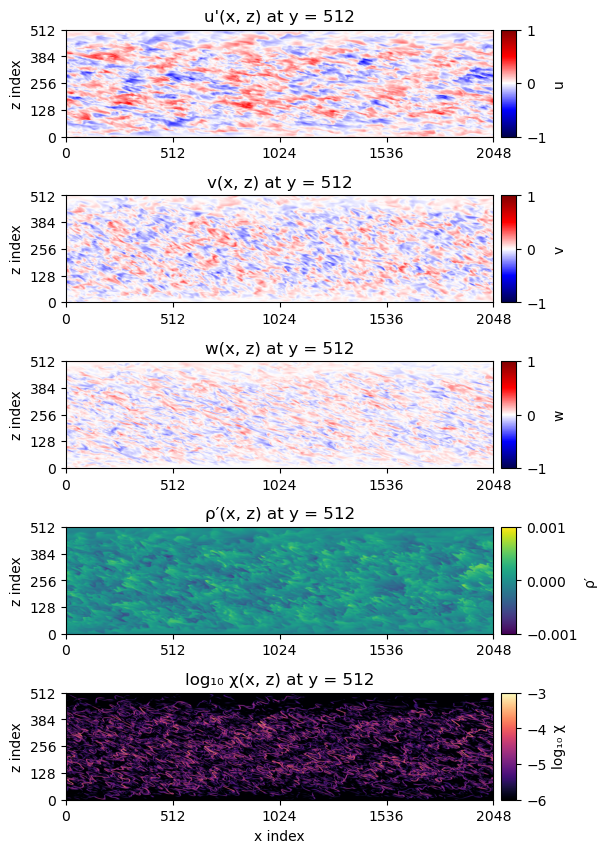

In [70]:
# Plot slices of the perturbations

# Pick a y index and plot vertical slices (here in the middle)
yIdx = p.Ny // 2

fig, axs = plt.subplots(5, 1, figsize=(10, 10))
fig.subplots_adjust(hspace=0.55)

imshow_with_cbar(axs[0], u[:, yIdx, :], "seismic", -1, 1, "u'")
axs[0].set_title(f"u'(x, z) at iy = {yIdx}")
set_index_axis(axs[0], "x", p.Nx, " ")
set_index_axis(axs[0], "y", p.Nz, "z index")

imshow_with_cbar(axs[1], v[:, yIdx, :], "seismic", -1, 1, "v")
axs[1].set_title(f"v(x, z) at iy = {yIdx}")
set_index_axis(axs[1], "x", p.Nx, " ")
set_index_axis(axs[1], "y", p.Nz, "z index")

imshow_with_cbar(axs[2], w[:, yIdx, :], "seismic", -1, 1, "w")
axs[2].set_title(f"w(x, z) at iy = {yIdx}")
set_index_axis(axs[2], "x", p.Nx, " ")
set_index_axis(axs[2], "y", p.Nz, "z index")

imshow_with_cbar(axs[3], r[:, yIdx, :], "viridis", -1e-3, 1e-3, "ρ′")
axs[3].set_title(f"ρ′(x, z) at iy = {yIdx}")
set_index_axis(axs[3], "x", p.Nx, " ")
set_index_axis(axs[3], "y", p.Nz, "z index")

imshow_with_cbar(axs[4], np.log10(chi[:, yIdx, :]), "magma", -6, -3, "log₁₀ χ")
axs[4].set_title(f"log₁₀ χ(x, z) at iy = {yIdx}")
set_index_axis(axs[4], "x", p.Nx, "x index")
set_index_axis(axs[4], "y", p.Nz, "z index")

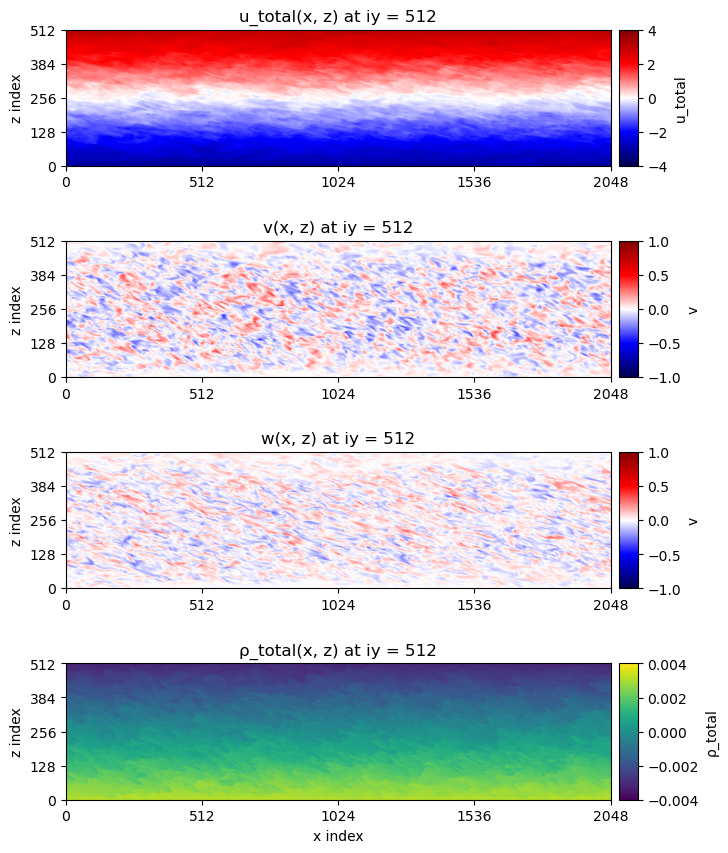

In [76]:
# Plot several slices of the TOTAL fields

# Define total fields
dz = p.Lz/p.Nz

def U_z_broadcast(p):
    # Miles: np.arange(-Nz/2, Nz/2) * Lz/Nz
    z_idx = np.arange(p.Nz) - p.Nz/2
    U = z_idx * dz                  # shape (Nz,)
    return U[None, :]               # shape (1, Nz)

def R_z_broadcast(p):
    # Miles: -flipud(dGrad * arange(0,Nz) * Lz/Nz)
    # This gives a linear background reversed in z.
    z_idx = np.arange(p.Nz) - p.Nz/2
    R = -(p.dGrad * z_idx * dz)     # shape (Nz,)
    R = R[::-1]                     # flipud
    return R[None, :]               # shape (1, Nz)

Uz = U_z_broadcast(p)   # (1, Nz)
Rz = R_z_broadcast(p)   # (1, Nz)

# Pick a y index and plot vertical slices (here in the middle)
yIdx = p.Ny // 2

fig, axs = plt.subplots(4, 1, figsize=(10, 10))
fig.subplots_adjust(hspace=0.55)

imshow_with_cbar(axs[0], u[:, yIdx, :] + Uz, "seismic", -4, 4, "u_total");  # <- note ;
axs[0].set_title(f"u_total(x, z) at iy = {yIdx}")
set_index_axis(axs[0], "x", p.Nx, " ")
set_index_axis(axs[0], "y", p.Nz, "z index")

imshow_with_cbar(axs[1], v[:, yIdx, :], "seismic", -1, 1, "v");  # v has no mean shear in setup
axs[1].set_title(f"v(x, z) at iy = {yIdx}")
set_index_axis(axs[1], "x", p.Nx, " ")
set_index_axis(axs[1], "y", p.Nz, "z index")

imshow_with_cbar(axs[2], w[:, yIdx, :], "seismic", -1, 1, "w");  # w has no mean shear in setup
axs[2].set_title(f"w(x, z) at iy = {yIdx}")
set_index_axis(axs[2], "x", p.Nx, " ")
set_index_axis(axs[2], "y", p.Nz, "z index")

imshow_with_cbar(axs[3], r[:, yIdx, :] + Rz, "viridis", -0.004, 0.004, "ρ_total");  # <- note ;
axs[3].set_title(f"ρ_total(x, z) at iy = {yIdx}")
set_index_axis(axs[3], "x", p.Nx, " ")
set_index_axis(axs[3], "y", p.Nz, "z index")
set_index_axis(axs[3], "x", p.Nx, "x index")

In [80]:
save_slice_figure(
    fig,
    p,
    slice_dir="y",
    idx=yIdx,
    outdir="figures",
    fmt="jpg",
    dpi=300
)

Saved → figures/R4P1_slice_y512_20260112_064845.jpg


PosixPath('figures/R4P1_slice_y512_20260112_064845.jpg')

In [24]:
p.Lz

6.283185307179586

In [67]:
print("u_total min:", np.min(u[:, yIdx, :] + Uz))
print("u_total max:", np.max(u[:, yIdx, :] + Uz))
print("r_total min:", np.min(r[:, yIdx, :] + Rz))
print("r_total max:", np.max(r[:, yIdx, :] + Rz))

u_total min: -3.2807446738989445
u_total max: 3.232720113822429
r_total min: -0.0032165326388526854
r_total max: 0.003186355261665069
